In [30]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

pce = pd.read_csv("PERSONAL_EXPENDITURE.csv")
saving = pd.read_csv("SAVING_RATE.csv")
credit = pd.read_csv("CREDIT_OWNED.csv")




In [31]:
for df_ in [pce, saving, credit]:
    df_["observation_date"] = pd.to_datetime(df_["observation_date"])
    df_.set_index("observation_date", inplace=True)
    df_.sort_index(inplace=True)


In [32]:
pce = pce.rename(columns={"PCEC96": "consumer_spending"})
saving = saving.rename(columns={"PSAVERT": "saving_rate"})
credit = credit.rename(columns={"TOTALSL": "credit_total"})
df = pce.join(saving, how="inner").join(credit, how="inner")
display(df.head)

<bound method NDFrame.head of                   consumer_spending  saving_rate  credit_total
observation_date                                              
2007-01-01                  11181.0          2.4    2457945.58
2007-02-01                  11178.2          2.8    2470049.92
2007-03-01                  11190.7          3.0    2484433.18
2007-04-01                  11201.5          3.0    2493729.77
2007-05-01                  11218.0          2.8    2510016.06
...                             ...          ...           ...
2025-07-01                  16547.5          4.3    5057212.70
2025-08-01                  16595.8          4.1    5059896.38
2025-09-01                  16614.3          4.0    5071365.99
2025-10-01                  16665.1          3.7    5080601.87
2025-11-01                  16715.4          3.5    5084831.24

[227 rows x 3 columns]>

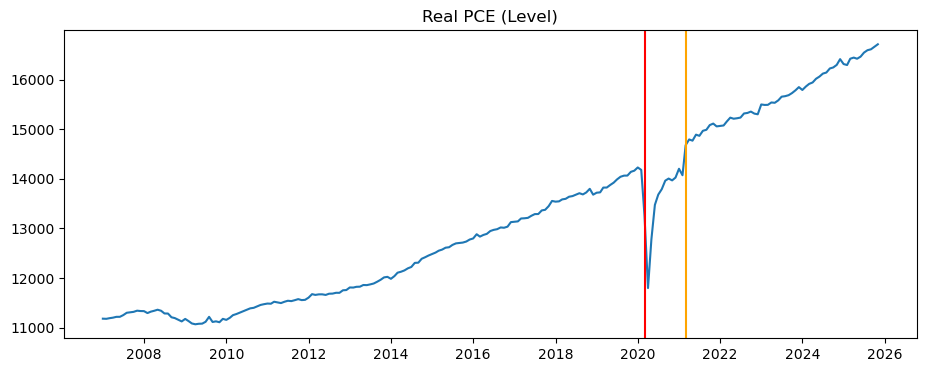

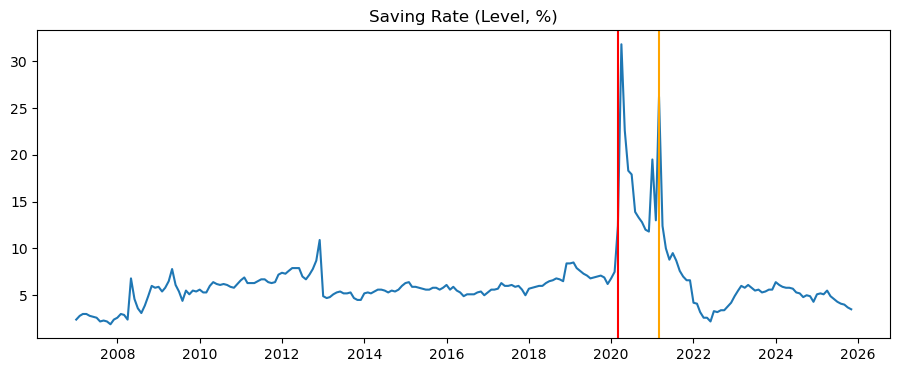

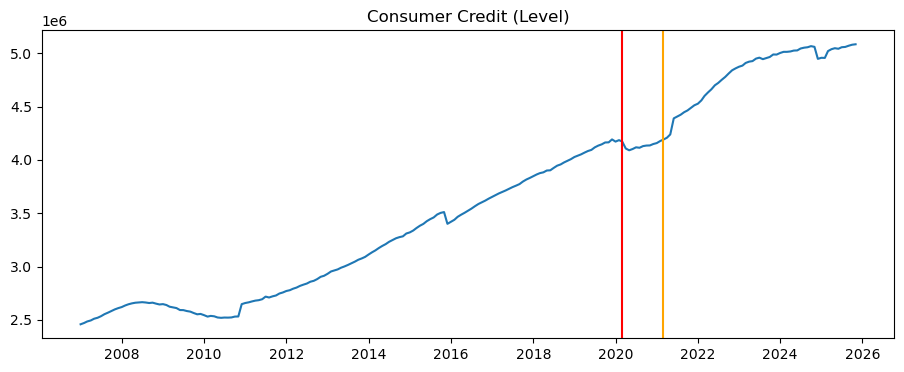

In [ ]:
df["t"] = np.arange(len(df))

# month seasonality dummies (captures repeating annual patterns)
df["month"] = df.index.month
month_dummies = pd.get_dummies(df["month"], prefix="m", drop_first=True)
df = pd.concat([df.drop(columns=["month"]), month_dummies], axis=1)

# Key dates (for plots + splitting train/test)
covid_start = pd.Timestamp("2020-03-01")
inflation_start = pd.Timestamp("2021-03-01")


def plot_series(col, title=None):
    plt.figure(figsize=(11, 4))
    plt.plot(df.index, df[col])
    plt.axvline(covid_start, color="red")
    plt.axvline(inflation_start, color="orange")
    plt.title(title or col)
    plt.show()

# Levels
plot_series("consumer_spending", "Real PCE (Level)")
plot_series("saving_rate", "Saving Rate (Level, %)")
plot_series("credit_total", "Consumer Credit (Level)")